# Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [9]:
members = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/members.csv")
songs = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/songs.csv")
songs_extra = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/song_extra_info.csv")
train = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/test.csv")

# Data Understanding

## Members Dataset

In [23]:
members.head()

,msno,city,bd,gender,registered_via,registration_init_time,expiration_date
0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1,0,NaN,7,20110820,20170920
1,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1,0,NaN,7,20150628,20170622
2,D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=,1,0,NaN,4,20160411,20170712
3,mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=,1,0,NaN,9,20150906,20150907
4,q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=,1,0,NaN,4,20170126,20170613


In [5]:
members.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   msno                    34403 non-null  object
 1   city                    34403 non-null  int64 
 2   bd                      34403 non-null  int64 
 3   gender                  14501 non-null  object
 4   registered_via          34403 non-null  int64 
 5   registration_init_time  34403 non-null  int64 
 6   expiration_date         34403 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.8+ MB


Null value counts

In [7]:
members.isna().sum()

,0
msno,0
city,0
bd,0
gender,19902
registered_via,0
registration_init_time,0
expiration_date,0


In [11]:
members.describe()

,city,bd,registered_via,registration_init_time,expiration_date
count,34403.000000,34403.000000,34403.000000,3.440300e+04,3.440300e+04
mean,5.371276,12.280935,5.953376,2.013994e+07,2.016901e+07
std,6.243929,18.170251,2.287534,2.954015e+04,7.320925e+03
min,1.000000,-43.000000,3.000000,2.004033e+07,1.970010e+07
25%,1.000000,0.000000,4.000000,2.012103e+07,2.017020e+07
50%,1.000000,0.000000,7.000000,2.015090e+07,2.017091e+07
75%,10.000000,25.000000,9.000000,2.016110e+07,2.017093e+07
max,22.000000,1051.000000,16.000000,2.017023e+07,2.020102e+07


Unrealistic Age values


 !! Outliers Lie beyond  22.0  and  52.0  !!


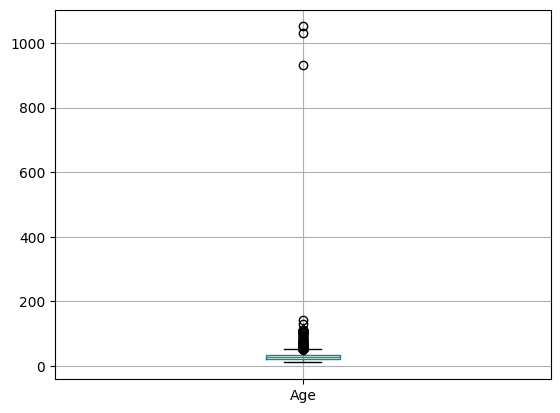

In [19]:
boxplots_bd = pd.DataFrame({"Age":members[members["bd"] > 10]["bd"]})
boxplots_bd.boxplot()

age_q1, age_q3 = (np.percentile(boxplots_bd,[25,75]))
age_iqr = (1.5*(age_q3-age_q1))
print("\n !! Outliers Lie beyond ",max(age_q1-age_iqr,age_q1)," and ",age_q3+age_iqr," !!")

Top Cities

In [28]:
members["city"].value_counts().sort_values(ascending=False).head()

,count
city,
1,19445
13,3395
5,2634
4,1732
15,1525


Top Registration Methods

In [29]:
members["registered_via"].value_counts().sort_values(ascending=False).head()

,count
registered_via,
4,11392
7,9433
9,8628
3,4879
13,70


## Songs Dataset

In [24]:
songs.head()

,song_id,song_length,genre_ids,artist_name,composer,lyricist,language
0,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,247640,465,張信哲 (Jeff Chang),董貞,何啟弘,3.0
1,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=,197328,444,BLACKPINK,TEDDY| FUTURE BOUNCE| Bekuh BOOM,TEDDY,31.0
2,DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=,231781,465,SUPER JUNIOR,NaN,NaN,31.0
3,dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=,273554,465,S.H.E,湯小康,徐世珍,3.0
4,W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=,140329,726,貴族精選,Traditional,Traditional,52.0


In [20]:
songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296320 entries, 0 to 2296319
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   song_id      object 
 1   song_length  int64  
 2   genre_ids    object 
 3   artist_name  object 
 4   composer     object 
 5   lyricist     object 
 6   language     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 122.6+ MB


Null value counts

In [21]:
songs.isna().sum()

,0
song_id,0
song_length,0
genre_ids,94116
artist_name,0
composer,1071358
lyricist,1945306
language,1


In [26]:
songs.describe()

,song_length,language
count,2.296320e+06,2.296319e+06
mean,2.469935e+05,3.237800e+01
std,1.609200e+05,2.433241e+01
min,1.850000e+02,-1.000000e+00
25%,1.836000e+05,-1.000000e+00
50%,2.266270e+05,5.200000e+01
75%,2.772690e+05,5.200000e+01
max,1.217385e+07,5.900000e+01


Columns that have multivalues

In [25]:
cols = []
for col in songs.select_dtypes(include=['object']).columns:
    if songs[col].astype(str).str.contains('|', regex=False).any():
        cols.append(col)
print("Columns containing '|':", cols)

Columns containing '|': ['genre_ids', 'artist_name', 'composer', 'lyricist']


Top Artists removing the "|"

In [30]:
songs["artist_name"].str.split("|").explode("artist_name").value_counts().sort_values(ascending=False)

,count
artist_name,
Various Artists,146117
証聲音樂圖書館 ECHO MUSIC,11276
Billy Vaughn,4849
รวมศิลปิน,4432
Richard Clayderman,4201
...,...
Pussy Riot,1
Neil Young,1
Factory Settings,1


Top Composers removing the "|"

In [31]:
songs["composer"].str.split("|").explode("composer").value_counts().sort_values(ascending=False)

,count
composer,
Neuromancer,18005
Johann Sebastian Bach,12284
Wolfgang Amadeus Mozart,10887
Traditional,10823
Marco Rinaldo,10803
...,...
Stéphane O'ney,1
Deanna Walker,1
Victoria Rivera,1


Top Lyricists removing the "|"

In [32]:
songs["lyricist"].str.split("|").explode("lyricist").value_counts().sort_values(ascending=False)

,count
lyricist,
Traditional,1846
―,1530
林夕,1031
Michael Ruland,832
Jr.,766
...,...
花盛,1
Philip Bliss,1
Oscar Poulsen,1


## Song Extra Info Dataset

In [33]:
songs_extra.head()

,song_id,name,isrc
0,LP7pLJoJFBvyuUwvu+oLzjT+bI+UeBPURCecJsX1jjs=,我們,TWUM71200043
1,ClazTFnk6r0Bnuie44bocdNMM3rdlrq0bCGAsGUWcHE=,Let Me Love You,QMZSY1600015
2,u2ja/bZE3zhCGxvbbOB3zOoUjx27u40cf5g09UXMoKQ=,原諒我,TWA530887303
3,92Fqsy0+p6+RHe2EoLKjHahORHR1Kq1TBJoClW9v+Ts=,Classic,USSM11301446
4,0QFmz/+rJy1Q56C1DuYqT9hKKqi5TUqx0sN0IwvoHrw=,愛投羅網,TWA471306001


In [34]:
songs_extra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2295971 entries, 0 to 2295970
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   song_id  object
 1   name     object
 2   isrc     object
dtypes: object(3)
memory usage: 52.6+ MB


Null value counts

In [35]:
songs_extra.isna().sum()

,0
song_id,0
name,3
isrc,136548


In [36]:
songs_extra.describe()

,song_id,name,isrc
count,2295971,2295968,2159423
unique,2295971,1168978,1806825
top,DYKJKSgDOKxb19XzOVO81176qTH0OIHCsfzFRm/BG+g=,Intro,GBPS81518952
freq,1,1734,207


Song_Id Intersection Values

In [40]:
songs_ids = set(songs['song_id'])
songs_extra_ids = set(songs_extra['song_id'])

# Song IDs in songs but not in songs_extra
songs_only_ids = songs_ids - songs_extra_ids
print(f"Song_ids in 'songs' but not in 'songs_extra': {len(songs_only_ids)}")

# Song IDs in songs_extra but not in songs
songs_extra_only_ids = songs_extra_ids - songs_ids
print(f"Song_ids in 'songs_extra' but not in 'songs': {len(songs_extra_only_ids)}")

# Common song IDs in both datasets
common_ids = songs_ids.intersection(songs_extra_ids)
print(f"Song_ids in both datasets: {len(common_ids)}")

Song_ids in 'songs' but not in 'songs_extra': 898
Song_ids in 'songs_extra' but not in 'songs': 549
Song_ids in both datasets: 2295422


Top isrc

In [41]:
songs_extra["isrc"].value_counts().sort_values(ascending=False).head()

,count
isrc,
GBPS81518952,207
GBPS81527416,205
GBPS81518950,195
GBPS81518680,195
GBPS81518682,194


## Train Dataset

In [42]:
train.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1


In [43]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 6 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   msno                object
 1   song_id             object
 2   source_system_tab   object
 3   source_screen_name  object
 4   source_type         object
 5   target              int64 
dtypes: int64(1), object(5)
memory usage: 337.7+ MB


Null value counts

In [44]:
train.isna().sum()

,0
msno,0
song_id,0
source_system_tab,24849
source_screen_name,414804
source_type,21539
target,0


In [45]:
train.describe()

,target
count,7.377418e+06
mean,5.035171e-01
std,4.999877e-01
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


Msno, Song_Id Intersection Values

In [60]:
train_msno_ids = set(train['msno'])
members_msno_ids = set(members['msno'])
common_msno_train_members = train_msno_ids.intersection(members_msno_ids)
msno_train_only = train_msno_ids - members_msno_ids
msno_members_only = members_msno_ids - train_msno_ids
print(f"msno: \t\t\t Train and Members: {len(common_msno_train_members)}, \t\t Train only: {len(msno_train_only)}, \t Members only: {len(msno_members_only)}")

train_song_ids = set(train['song_id'])
songs_song_ids = set(songs['song_id'])
common_song_ids_train_songs = train_song_ids.intersection(songs_song_ids)
song_ids_train_only_songs = train_song_ids - songs_song_ids
song_ids_songs_only_train = songs_song_ids - train_song_ids
print(f"song_id (songs): \t Train and Songs: {len(common_song_ids_train_songs)}, \t\t Train only: {len(song_ids_train_only_songs)}, \t Songs only: {len(song_ids_songs_only_train)}")

songs_extra_song_ids = set(songs_extra['song_id'])
common_song_ids_train_songs_extra = train_song_ids.intersection(songs_extra_song_ids)
song_ids_train_only_songs_extra = train_song_ids - songs_extra_song_ids
song_ids_songs_extra_only_train = songs_extra_song_ids - train_song_ids
print(f"song_id (songs_extra): \t Train and Songs_Extra: {len(common_song_ids_train_songs_extra)}, \t Train only: {len(song_ids_train_only_songs_extra)}, \t Songs_Extra only: {len(song_ids_songs_extra_only_train)}")

msno: 			 Train and Members: 30755, 		 Train only: 0, 	 Members only: 3648
song_id (songs): 	 Train and Songs: 359914, 		 Train only: 52, 	 Songs only: 1936406
song_id (songs_extra): 	 Train and Songs_Extra: 359807, 	 Train only: 159, 	 Songs_Extra only: 1936164


Target Distribution

In [63]:
train["target"].value_counts()

,count
target,
1,3714656
0,3662762


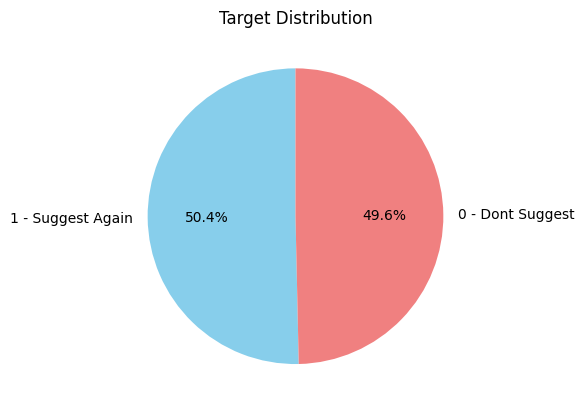

In [114]:
plt.pie(train["target"].value_counts(), autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'], labels = ["1 - Suggest Again", "0 - Dont Suggest"])
plt.title('Target Distribution')
plt.show()

## Test Dataset

In [72]:
test.head()

,id,msno,song_id,source_system_tab,source_screen_name,source_type
0,0,V8ruy7SGk7tDm3zA51DPpn6qutt+vmKMBKa21dp54uM=,WmHKgKMlp1lQMecNdNvDMkvIycZYHnFwDT72I5sIssc=,my library,Local playlist more,local-library
1,1,V8ruy7SGk7tDm3zA51DPpn6qutt+vmKMBKa21dp54uM=,y/rsZ9DC7FwK5F2PK2D5mj+aOBUJAjuu3dZ14NgE0vM=,my library,Local playlist more,local-library
2,2,/uQAlrAkaczV+nWCd2sPF2ekvXPRipV7q0l+gbLuxjw=,8eZLFOdGVdXBSqoAv5nsLigeH2BvKXzTQYtUM53I0k4=,discover,NaN,song-based-playlist
3,3,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,ztCf8thYsS4YN3GcIL/bvoxLm/T5mYBVKOO4C9NiVfQ=,radio,Radio,radio
4,4,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,MKVMpslKcQhMaFEgcEQhEfi5+RZhMYlU3eRDpySrH8Y=,radio,Radio,radio


In [73]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556790 entries, 0 to 2556789
Data columns (total 6 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   id                  int64 
 1   msno                object
 2   song_id             object
 3   source_system_tab   object
 4   source_screen_name  object
 5   source_type         object
dtypes: int64(1), object(5)
memory usage: 117.0+ MB


Null value counts

In [74]:
test.isna().sum()

,0
id,0
msno,0
song_id,0
source_system_tab,8442
source_screen_name,162883
source_type,7297


In [75]:
test.describe()

,id
count,2.556790e+06
mean,1.278394e+06
std,7.380818e+05
min,0.000000e+00
25%,6.391972e+05
50%,1.278394e+06
75%,1.917592e+06
max,2.556789e+06


Msno, Song_Id Intersection Values

In [76]:
test_msno_ids = set(test['msno'])
members_msno_ids = set(members['msno'])
common_msno_test_members = test_msno_ids.intersection(members_msno_ids)
msno_test_only = test_msno_ids - members_msno_ids
msno_members_only = members_msno_ids - test_msno_ids
print(f"msno: \t\t\t Test and Members: {len(common_msno_test_members)}, \t\t Test only: {len(msno_test_only)}, \t Members only: {len(msno_members_only)}")

test_song_ids = set(test['song_id'])
songs_song_ids = set(songs['song_id'])
common_song_ids_test_songs = test_song_ids.intersection(songs_song_ids)
song_ids_test_only_songs = test_song_ids - songs_song_ids
song_ids_songs_only_test = songs_song_ids - test_song_ids
print(f"song_id (songs): \t Test and Songs: {len(common_song_ids_test_songs)}, \t\t Test only: {len(song_ids_test_only_songs)}, \t Songs only: {len(song_ids_songs_only_test)}")

songs_extra_song_ids = set(songs_extra['song_id'])
common_song_ids_test_songs_extra = test_song_ids.intersection(songs_extra_song_ids)
song_ids_test_only_songs_extra = test_song_ids - songs_extra_song_ids
song_ids_songs_extra_only_test = songs_extra_song_ids - test_song_ids
print(f"song_id (songs_extra): \t Test and Songs_Extra: {len(common_song_ids_test_songs_extra)}, \t Test only: {len(song_ids_test_only_songs_extra)}, \t Songs_Extra only: {len(song_ids_songs_extra_only_test)}")

msno: 			 Test and Members: 25131, 		 Test only: 0, 	 Members only: 9272
song_id (songs): 	 Test and Songs: 224739, 		 Test only: 14, 	 Songs only: 2071581
song_id (songs_extra): 	 Test and Songs_Extra: 224638, 	 Test only: 115, 	 Songs_Extra only: 2071333


# Visualizations

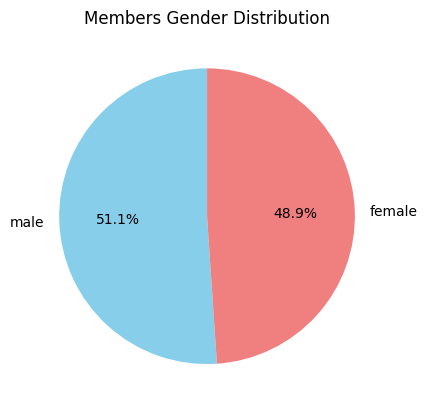

In [111]:
plt.pie(members['gender'].value_counts(), autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'], labels = members['gender'].value_counts().index)
plt.title('Members Gender Distribution')
plt.show()

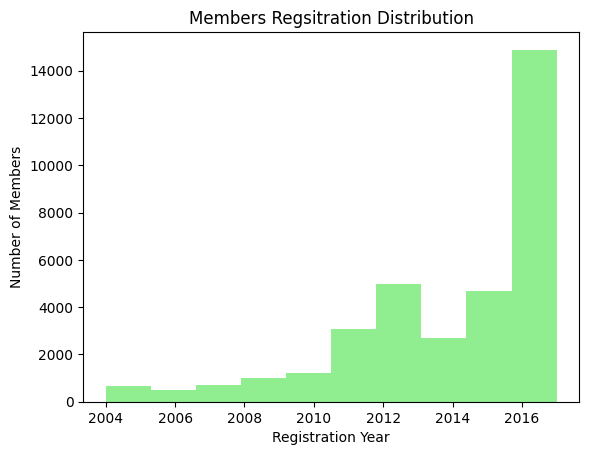

In [110]:
members['registration_year'] = members['registration_init_time'].astype(str).str[:4].astype(int)
plt.hist(members['registration_year'], color=["lightgreen"])
plt.title('Members Regsitration Distribution')
plt.xlabel('Registration Year')
plt.ylabel('Number of Members')
plt.show()

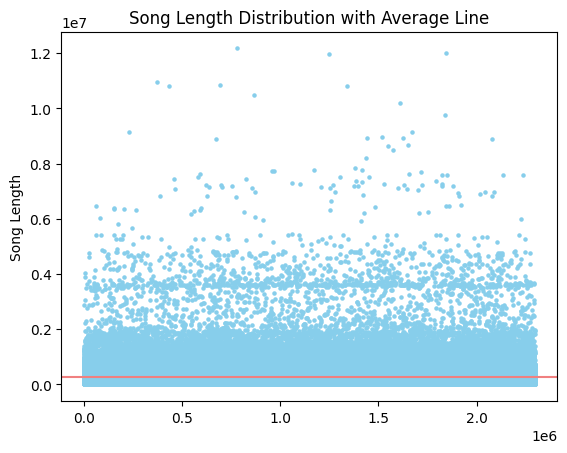

In [125]:
plt.scatter(songs["song_length"].index, songs["song_length"].values, s=5, color="skyblue")
plt.axhline(y=songs[songs["song_length"]>=100000]["song_length"].mean(), color='lightcoral', linestyle='-')
plt.title('Song Length Distribution with Average Line')
plt.ylabel('Song Length')
plt.show()

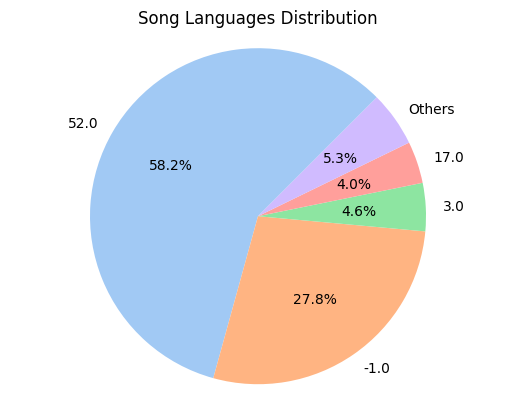

In [138]:
language_counts = songs['language'].value_counts(dropna=True)
top_4_languages = language_counts.head(4)
others_count = language_counts.iloc[4:].sum()
language_counts_for_pie = pd.concat([top_4_languages, pd.Series({'Others': others_count})])

plt.pie(language_counts_for_pie, labels=language_counts_for_pie.index, autopct='%1.1f%%', startangle=45, colors=sns.color_palette('pastel'))
plt.title('Song Languages Distribution')
plt.axis('equal')
plt.show()


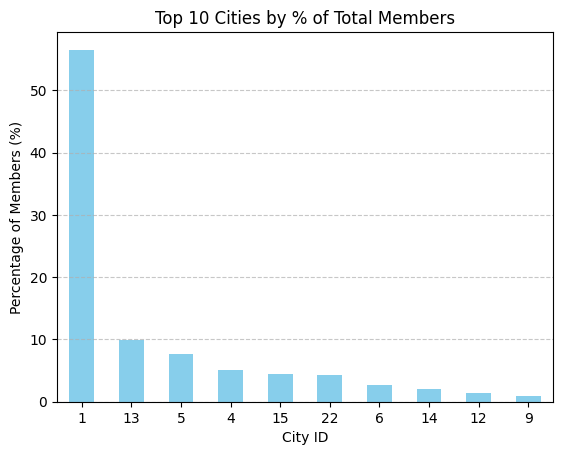

In [147]:
city_percentages = members['city'].value_counts(normalize=True) * 100

top_cities = city_percentages.head(10)
top_cities.plot(kind='bar', color='skyblue')

plt.title('Top 10 Cities by % of Total Members')
plt.xlabel('City ID')
plt.ylabel('Percentage of Members (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()